# TS-SatFire -- HybridUNet v3 -- Burned Area Mapping

**Changes from v2 (the previous trained model):**
- Distance-weighted loss: false positives far from any real fire pixel are penalized more heavily
- `FIRE_CLASS_WEIGHT` raised from 150 to 300 to address the FP-heavy failure mode seen in v2 inference (FP=13.7M vs FN=1.5M)
- `TRAIN_INTERVAL` reduced from 2 to 1, roughly doubling training samples per epoch
- `VAL_FRACTION` raised from 0.10 to 0.15 for a more stable validation signal
- `NUM_EPOCHS` raised from 20 to 30 -- training curves showed no convergence at epoch 20
- Inference confidence threshold raised to 0.55 to cut spatially-unanchored false positives
- All checkpoint and metadata filenames updated to `_v3`
- Model class renamed `HybridUNetV3`
- Training curves saved as `training_curves_v3.png`

Dataset: TS-SatFire (Zhao et al. 2025, Scientific Data 12:1817)
https://www.kaggle.com/datasets/z789456sx/ts-satfire/data

In [1]:
import os
import sys
import glob
import json
import math
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import distance_transform_edt
from tqdm.auto import tqdm

import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler

print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}: {props.name}  {props.total_memory // 1024**2} MB')

Python  : 3.12.12
PyTorch : 2.9.0+cu126
CUDA    : True
  GPU 0: Tesla T4  14912 MB
  GPU 1: Tesla T4  14912 MB


## Configuration

In [2]:
# ---------------------------------------------------------------
# Paths
# ---------------------------------------------------------------
DATA_ROOT  = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR = '/kaggle/working'
CKPT_PATH  = os.path.join(OUTPUT_DIR, 'hybridunet_v3_ba_best.pt')
STATS_PATH = os.path.join(OUTPUT_DIR, 'norm_stats_v3.npz')
META_PATH  = os.path.join(OUTPUT_DIR, 'run_meta_v3.json')

# ---------------------------------------------------------------
# Model / data
# ---------------------------------------------------------------
TIME_STEPS     = 2
CHANS_PER_STEP = 26
IN_CHANNELS    = CHANS_PER_STEP * TIME_STEPS   # 52
PATCH_SIZE     = 128
BASE_CH        = 32
N_HEADS        = 2      # must divide CHANS_PER_STEP=26: valid: 1,2,13,26
FOCAL_GAMMA    = 1.5

# ---------------------------------------------------------------
# Training
# ---------------------------------------------------------------
NUM_EPOCHS     = 12
BATCH_SIZE     = 16
LR             = 1e-4
WEIGHT_DECAY   = 1e-5
WARMUP_EPOCHS  = 1
TRAIN_INTERVAL = 1      # reduced from 2: ~doubles training samples per epoch
VAL_INTERVAL   = 4
VAL_FRACTION   = 0.15   # raised from 0.10: more stable val signal
SEED           = 42

# Raised from 150 to 300: v2 inference showed FP=13.7M vs FN=1.5M
# The model was too willing to predict fire. Stronger penalty on background errors.
FIRE_CLASS_WEIGHT = 300.0

# Distance transform penalty: multiplier on FP pixels far from real fire
# A pixel predicted as fire that is DIST_MAX_PX away gets DIST_SIGMA x more penalty
DIST_MAX_PX    = 50     # distances beyond this are clipped before normalisation
DIST_SIGMA     = 5.0    # max additional weight multiplier for far false positives

MIN_FIRE_PIXELS  = 50
MAX_NEG_RATIO    = 3

# Inference threshold -- raised from 0.5 to cut spatially-unanchored FP
INFER_THRESHOLD  = 0.55

SAVE_FIGURES = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_autocast():
    return torch.amp.autocast('cuda') if device.type == 'cuda' \
           else torch.amp.autocast('cpu', dtype=torch.float32)

print(f'Device            : {device}')
print(f'TIME_STEPS        : {TIME_STEPS}')
print(f'IN_CHANNELS       : {IN_CHANNELS}')
print(f'NUM_EPOCHS        : {NUM_EPOCHS}')
print(f'WARMUP_EPOCHS     : {WARMUP_EPOCHS}')
print(f'TRAIN_INTERVAL    : {TRAIN_INTERVAL}')
print(f'VAL_FRACTION      : {VAL_FRACTION}')
print(f'PATCH_SIZE        : {PATCH_SIZE}')
print(f'BATCH_SIZE        : {BATCH_SIZE}')
print(f'N_HEADS           : {N_HEADS}')
print(f'FOCAL_GAMMA       : {FOCAL_GAMMA}')
print(f'FIRE_CLASS_WEIGHT : {FIRE_CLASS_WEIGHT}')
print(f'DIST_MAX_PX       : {DIST_MAX_PX}')
print(f'DIST_SIGMA        : {DIST_SIGMA}')
print(f'INFER_THRESHOLD   : {INFER_THRESHOLD}')
print(f'26 % N_HEADS      : {26 % N_HEADS}  (must be 0)')

Device            : cuda
TIME_STEPS        : 2
IN_CHANNELS       : 52
NUM_EPOCHS        : 12
WARMUP_EPOCHS     : 1
TRAIN_INTERVAL    : 1
VAL_FRACTION      : 0.15
PATCH_SIZE        : 128
BATCH_SIZE        : 16
N_HEADS           : 2
FOCAL_GAMMA       : 1.5
FIRE_CLASS_WEIGHT : 300.0
DIST_MAX_PX       : 50
DIST_SIGMA        : 5.0
INFER_THRESHOLD   : 0.55
26 % N_HEADS      : 0  (must be 0)


## Dataset discovery and splits

In [3]:
if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'Dataset not found at {DATA_ROOT}')

all_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_ROOT, '*'))
    if os.path.isdir(d)
])

REQUIRED = {'VIIRS_Day', 'VIIRS_Night', 'FirePred'}
fire_dirs, invalid = [], []
for d in all_dirs:
    sub = set(os.listdir(d))
    if REQUIRED.issubset(sub):
        fire_dirs.append(d)
    else:
        invalid.append(os.path.basename(d))

print(f'Total folders   : {len(all_dirs)}')
print(f'Valid fires     : {len(fire_dirs)}')
print(f'Invalid (skip)  : {len(invalid)}')

def fp_chan_count(fd):
    files = sorted(glob.glob(os.path.join(fd, 'FirePred', '*.tif')))
    if not files:
        return -1
    with rasterio.open(files[0]) as src:
        return src.count

bad       = [fd for fd in fire_dirs if fp_chan_count(fd) != 19]
fire_dirs = [fd for fd in fire_dirs if fd not in set(bad)]
print(f'Removed non-standard FirePred fires: {len(bad)}')
print(f'Usable fires    : {len(fire_dirs)}')

random.seed(SEED)
test_fires  = [fd for fd in fire_dirs if '2021' in os.path.basename(fd)]
train_pool  = [fd for fd in fire_dirs if fd not in set(test_fires)]
random.shuffle(train_pool)
n_val       = max(1, int(len(train_pool) * VAL_FRACTION))
val_fires   = train_pool[:n_val]
train_fires = train_pool[n_val:]

print(f'\nSplit summary:')
print(f'  train : {len(train_fires)} fires')
print(f'  val   : {len(val_fires)} fires')
print(f'  test  : {len(test_fires)} fires')
print(f'FIRE_CLASS_WEIGHT : {FIRE_CLASS_WEIGHT}')

Total folders   : 192
Valid fires     : 178
Invalid (skip)  : 14
Removed non-standard FirePred fires: 5
Usable fires    : 173

Split summary:
  train : 127 fires
  val   : 22 fires
  test  : 24 fires
FIRE_CLASS_WEIGHT : 300.0


## EDA

Surveying fires:   0%|          | 0/173 [00:00<?, ?it/s]

      n_days         ba_pos_days        
        mean min max        mean min max
split                                   
test    35.6  10  87        16.0   0  70
train   17.9   3  65         7.2   0  36
val     17.0   7  41         7.8   0  31


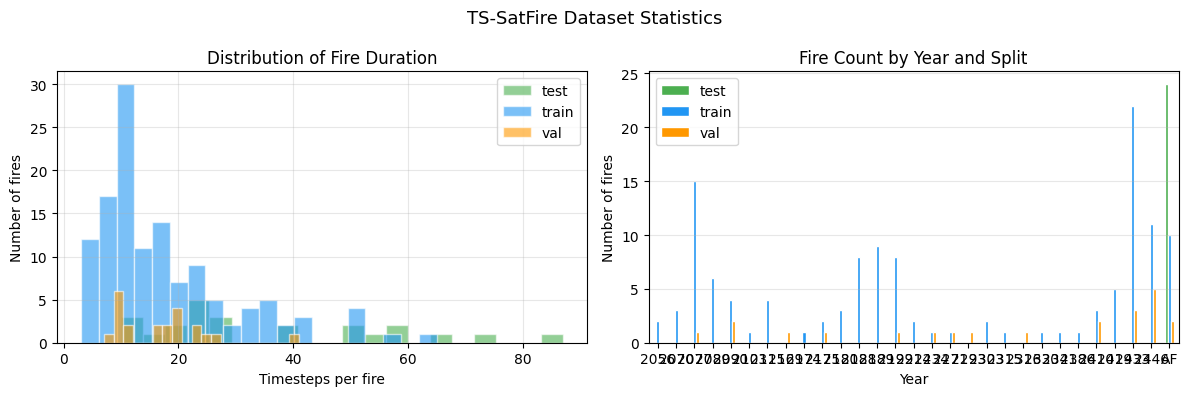

EDA complete.


In [4]:
records = []
for fd in tqdm(fire_dirs, desc='Surveying fires'):
    fid       = os.path.basename(fd)
    day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
    fp_files  = sorted(glob.glob(os.path.join(fd, 'FirePred',  '*.tif')))
    year      = fid[:4] if fid[:4].isdigit() else 'AF'
    n_days    = len(day_files)
    with rasterio.open(day_files[0]) as src:
        h, w = src.height, src.width
    ba_pos = sum(
        1 for fp in fp_files
        if rasterio.open(fp).__enter__().read(3).max() > 0
    )
    split = ('test'  if fd in set(test_fires) else
             'val'   if fd in set(val_fires)  else 'train')
    records.append({'fire_id': fid, 'year': year, 'split': split,
                    'n_days': n_days, 'height': h, 'width': w,
                    'ba_pos_days': ba_pos})

df = pd.DataFrame(records)
print(df.groupby('split')[['n_days', 'ba_pos_days']].agg(['mean','min','max']).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}
for split, grp in df.groupby('split'):
    axes[0].hist(grp['n_days'], bins=20, alpha=0.6,
                 color=colors[split], label=split, edgecolor='white')
axes[0].set_xlabel('Timesteps per fire')
axes[0].set_ylabel('Number of fires')
axes[0].set_title('Distribution of Fire Duration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

year_counts = df.groupby(['year', 'split']).size().unstack(fill_value=0)
year_counts.plot(kind='bar', ax=axes[1],
                 color=[colors[s] for s in year_counts.columns],
                 edgecolor='white')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of fires')
axes[1].set_title('Fire Count by Year and Split')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend()

plt.suptitle('TS-SatFire Dataset Statistics', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'eda_stats_v3.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete.')

## Normalisation statistics

Channels 8 (NDVI) and 9 (EVI) have means around 4300 and stds around 2500 which overwhelm
all other channels. Each channel is clipped at the 1st and 99th percentile before computing
mean and std to produce stable normalisation statistics.

Computing normalisation statistics (2-pass with percentile clipping)...


Pass 1 / percentiles:   0%|          | 0/25 [00:00<?, ?it/s]

Pass 2 / mean+std:   0%|          | 0/25 [00:00<?, ?it/s]

Saved to /kaggle/working/norm_stats_v3.npz
Means range: [-0.123, 4260.868]
Stds  range: [0.002,  2406.180]


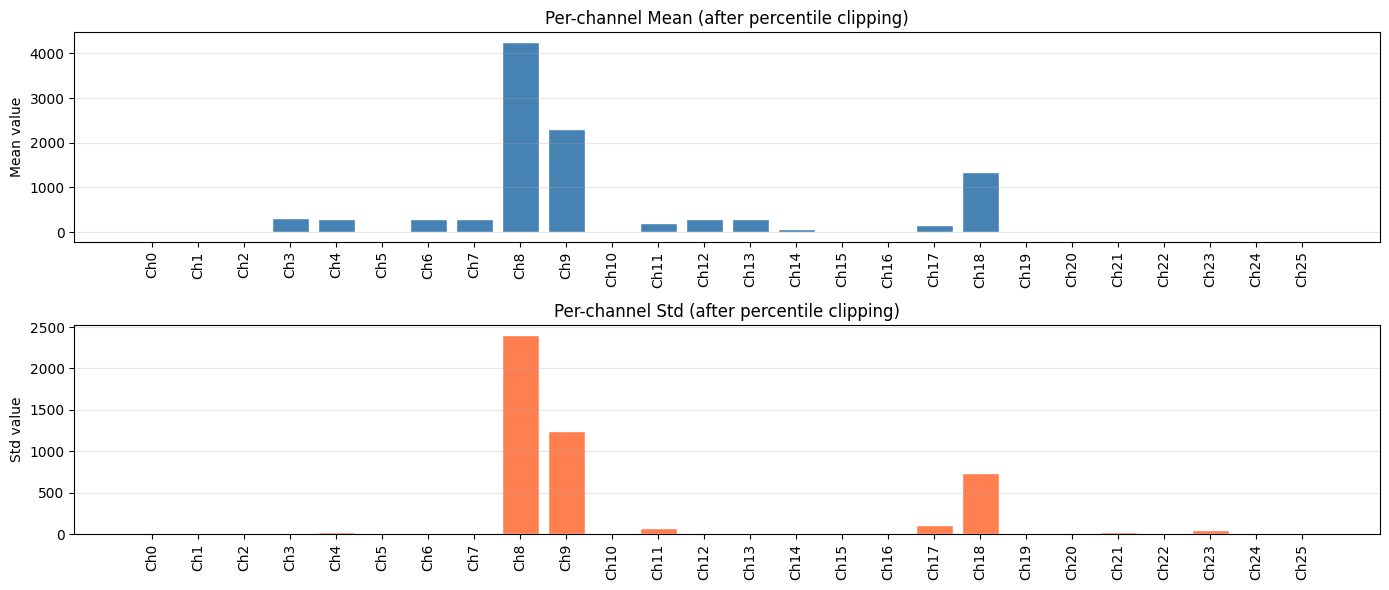

In [5]:
def compute_norm_stats(fire_dirs, n_fires=25, n_days=3, seed=SEED,
                       clip_percentile=99):
    rng    = random.Random(seed)
    sample = rng.sample(fire_dirs, min(n_fires, len(fire_dirs)))

    all_vals = [[] for _ in range(CHANS_PER_STEP)]
    for fd in tqdm(sample, desc='Pass 1 / percentiles'):
        day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
        for dp in random.sample(day_files, min(n_days, len(day_files))):
            date_str   = os.path.basename(dp).replace('_VIIRS_Day.tif', '')
            night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')
            with rasterio.open(dp) as src:
                d = src.read().astype(np.float32)
            spectral = d[:6]
            night = np.full((2, d.shape[1], d.shape[2]), np.nan, np.float32)
            if os.path.exists(night_path):
                with rasterio.open(night_path) as src:
                    night = src.read().astype(np.float32)[:2]
            H, W = spectral.shape[1], spectral.shape[2]
            if os.path.exists(fp_path):
                with rasterio.open(fp_path) as src:
                    fp = src.read().astype(np.float32)
                fp_t = torch.from_numpy(fp).unsqueeze(0)
                fp_t = F.interpolate(fp_t, size=(H, W), mode='nearest')
                fp   = fp_t.squeeze(0).numpy()
                aux  = np.concatenate([fp[:2], fp[3:]], axis=0)
            else:
                aux = np.zeros((18, H, W), np.float32)
            frame = np.concatenate([spectral, night, aux], axis=0)
            for c in range(CHANS_PER_STEP):
                vals = frame[c][np.isfinite(frame[c])].ravel()
                if vals.size > 0:
                    all_vals[c].append(vals[::max(1, len(vals)//2000)])

    lo_bounds = np.zeros(CHANS_PER_STEP, np.float32)
    hi_bounds = np.zeros(CHANS_PER_STEP, np.float32)
    for c in range(CHANS_PER_STEP):
        if all_vals[c]:
            v = np.concatenate(all_vals[c])
            lo_bounds[c] = np.percentile(v, 100 - clip_percentile)
            hi_bounds[c] = np.percentile(v, clip_percentile)

    sums    = np.zeros(CHANS_PER_STEP, np.float64)
    sq_sums = np.zeros(CHANS_PER_STEP, np.float64)
    counts  = np.zeros(CHANS_PER_STEP, np.float64)
    for fd in tqdm(sample, desc='Pass 2 / mean+std'):
        day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
        for dp in random.sample(day_files, min(n_days, len(day_files))):
            date_str   = os.path.basename(dp).replace('_VIIRS_Day.tif', '')
            night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')
            with rasterio.open(dp) as src:
                d = src.read().astype(np.float32)
            spectral = d[:6]
            night = np.full((2, d.shape[1], d.shape[2]), np.nan, np.float32)
            if os.path.exists(night_path):
                with rasterio.open(night_path) as src:
                    night = src.read().astype(np.float32)[:2]
            H, W = spectral.shape[1], spectral.shape[2]
            if os.path.exists(fp_path):
                with rasterio.open(fp_path) as src:
                    fp = src.read().astype(np.float32)
                fp_t = torch.from_numpy(fp).unsqueeze(0)
                fp_t = F.interpolate(fp_t, size=(H, W), mode='nearest')
                fp   = fp_t.squeeze(0).numpy()
                aux  = np.concatenate([fp[:2], fp[3:]], axis=0)
            else:
                aux = np.zeros((18, H, W), np.float32)
            frame = np.concatenate([spectral, night, aux], axis=0)
            for c in range(CHANS_PER_STEP):
                vals = frame[c][np.isfinite(frame[c])]
                vals = np.clip(vals, lo_bounds[c], hi_bounds[c])
                sums[c]    += vals.sum()
                sq_sums[c] += (vals ** 2).sum()
                counts[c]  += vals.size

    means = (sums / np.maximum(counts, 1)).astype(np.float32)
    stds  = np.sqrt(np.maximum(
        sq_sums / np.maximum(counts, 1) - means ** 2, 1e-6
    )).astype(np.float32)
    return means, stds, lo_bounds, hi_bounds


if os.path.exists(STATS_PATH):
    data       = np.load(STATS_PATH)
    CHAN_MEANS  = data['means']
    CHAN_STDS   = data['stds']
    CLIP_LO     = data['clip_lo']
    CLIP_HI     = data['clip_hi']
    print(f'Loaded normalisation stats from {STATS_PATH}')
else:
    print('Computing normalisation statistics (2-pass with percentile clipping)...')
    CHAN_MEANS, CHAN_STDS, CLIP_LO, CLIP_HI = compute_norm_stats(train_fires)
    np.savez(STATS_PATH, means=CHAN_MEANS, stds=CHAN_STDS,
             clip_lo=CLIP_LO, clip_hi=CLIP_HI)
    print(f'Saved to {STATS_PATH}')

print(f'Means range: [{CHAN_MEANS.min():.3f}, {CHAN_MEANS.max():.3f}]')
print(f'Stds  range: [{CHAN_STDS.min():.3f},  {CHAN_STDS.max():.3f}]')

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
ch_labels = [f'Ch{i}' for i in range(CHANS_PER_STEP)]
axes[0].bar(ch_labels, CHAN_MEANS, color='steelblue', edgecolor='white')
axes[0].set_title('Per-channel Mean (after percentile clipping)')
axes[0].set_ylabel('Mean value')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, alpha=0.3, axis='y')
axes[1].bar(ch_labels, CHAN_STDS, color='coral', edgecolor='white')
axes[1].set_title('Per-channel Std (after percentile clipping)')
axes[1].set_ylabel('Std value')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig(os.path.join(OUTPUT_DIR, 'channel_stats_v3.png'), dpi=150, bbox_inches='tight')
plt.show()

## Dataset

The key addition in v3 is the distance weight map returned alongside each sample.

For each label patch, `scipy.ndimage.distance_transform_edt` computes the Euclidean
distance from every background pixel to the nearest burned pixel. This map is
normalised to `[1, 1 + DIST_SIGMA]` so pixels far from any real fire receive a
higher loss multiplier when the model incorrectly predicts them as fire.
The map is returned as a third tensor from `__getitem__` and consumed by the loss.

In [6]:
def make_distance_weight_map(label_np, max_dist=DIST_MAX_PX, sigma=DIST_SIGMA):
    """
    Compute a per-pixel loss weight map from a binary burned-area label.

    Parameters
    ----------
    label_np : np.ndarray  shape (H, W), dtype float32, values in {0, 1}
    max_dist : int   distances beyond this are clipped before normalisation
    sigma    : float maximum additional weight multiplier for far-from-fire pixels

    Returns
    -------
    weight_map : np.ndarray  shape (H, W), dtype float32
                 Values in [1.0, 1.0 + sigma].
                 Background pixels close to fire -> weight near 1.0
                 Background pixels far from fire -> weight near 1.0 + sigma
                 Fire pixels -> always 1.0 (no extra penalty on true fire)
    """
    burned = (label_np > 0).astype(np.uint8)
    if burned.sum() == 0:
        # No fire in this patch -- uniform weight, nothing to anchor on
        return np.ones_like(label_np, dtype=np.float32)
    # Distance from each pixel to the nearest fire pixel
    dist = distance_transform_edt(1 - burned).astype(np.float32)
    dist = np.clip(dist, 0.0, float(max_dist)) / float(max_dist)  # [0, 1]
    weight_map = 1.0 + dist * sigma                                 # [1, 1+sigma]
    # Fire pixels themselves should not be penalised by distance
    weight_map[burned == 1] = 1.0
    return weight_map.astype(np.float32)


class TSSatFireDataset(Dataset):

    def __init__(self, fire_dirs, task='ba', time_steps=TIME_STEPS,
                 interval=1, patch_size=PATCH_SIZE,
                 means=None, stds=None,
                 clip_lo=None, clip_hi=None,
                 augment=False):
        self.task       = task
        self.T          = time_steps
        self.interval   = interval
        self.patch_size = patch_size
        self.means      = means
        self.stds       = stds
        self.clip_lo    = clip_lo
        self.clip_hi    = clip_hi
        self.augment    = augment
        self.samples    = []
        self._build_index(fire_dirs)

    def _build_index(self, fire_dirs):
        skipped    = 0
        n_pos      = 0
        n_neg      = 0
        n_neg_kept = 0
        rng = random.Random(SEED)

        for fd in fire_dirs:
            fp_files = sorted(glob.glob(os.path.join(fd, 'FirePred', '*.tif')))
            if fp_files:
                with rasterio.open(fp_files[0]) as src:
                    if src.count != 19:
                        skipped += 1
                        continue
            day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
            if len(day_files) < self.T:
                skipped += 1
                continue
            n     = len(day_files)
            start = 0
            while start + self.T <= n:
                last_day = day_files[start + self.T - 1]
                date_str = os.path.basename(last_day).replace('_VIIRS_Day.tif', '')
                fp_path  = os.path.join(fd, 'FirePred', f'{date_str}_FirePred.tif')

                fire_px = 0
                if os.path.exists(fp_path):
                    with rasterio.open(fp_path) as src:
                        lbl = src.read(3).astype(np.float32)
                    H, W = lbl.shape
                    if self.patch_size and H > self.patch_size and W > self.patch_size:
                        r0 = (H - self.patch_size) // 2
                        c0 = (W - self.patch_size) // 2
                        p  = self.patch_size
                        lbl = lbl[r0:r0+p, c0:c0+p]
                    fire_px = int((lbl > 0).sum())

                is_positive = fire_px >= MIN_FIRE_PIXELS
                if is_positive:
                    n_pos += 1
                    keep = True
                else:
                    n_neg += 1
                    keep = rng.random() < 1.0 / (MAX_NEG_RATIO + 1)
                    if keep:
                        n_neg_kept += 1

                if keep:
                    self.samples.append({
                        'fire_dir'  : fd,
                        'day_files' : day_files,
                        'start'     : start,
                        'end'       : start + self.T - 1,
                    })
                start += self.interval

        print(f'Dataset: {len(self.samples)} samples '
              f'(T={self.T}, interval={self.interval}, skipped={skipped})')
        print(f'  positive patches : {n_pos}')
        print(f'  neg kept/total   : {n_neg_kept}/{n_neg}  '
              f'(ratio ~{MAX_NEG_RATIO}:1)')

    @staticmethod
    def _date(path):
        return os.path.basename(path).replace('_VIIRS_Day.tif', '')

    def _load_timestep(self, fd, day_path, H, W):
        date_str   = self._date(day_path)
        night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
        fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')

        with rasterio.open(day_path) as src:
            day_arr = src.read().astype(np.float32)
        spectral = day_arr[:6, :H, :W]

        if os.path.exists(night_path):
            with rasterio.open(night_path) as src:
                night = src.read().astype(np.float32)[:2, :H, :W]
        else:
            night = np.full((2, H, W), np.nan, np.float32)

        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                fp = src.read().astype(np.float32)
            if fp.shape[1] != H or fp.shape[2] != W:
                fp = F.interpolate(torch.from_numpy(fp).unsqueeze(0),
                                   size=(H, W), mode='nearest').squeeze(0).numpy()
            # channel index 2 (fp band 3) is the BA label -- excluded from input
            aux = np.concatenate([fp[:2], fp[3:]], axis=0)  # (18, H, W)
        else:
            aux = np.zeros((18, H, W), np.float32)

        return np.concatenate([spectral, night, aux], axis=0)  # (26, H, W)

    def _load_label(self, fd, day_path, H, W):
        date_str = self._date(day_path)
        fp_path  = os.path.join(fd, 'FirePred', f'{date_str}_FirePred.tif')
        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                ch2 = src.read(3).astype(np.float32)
            if ch2.shape[0] != H or ch2.shape[1] != W:
                ch2 = F.interpolate(
                    torch.from_numpy(ch2).unsqueeze(0).unsqueeze(0),
                    size=(H, W), mode='nearest').squeeze().numpy()
            return (ch2 > 0).astype(np.float32)
        return np.zeros((H, W), np.float32)

    def _thermal_cummax(self, fd, all_day_files, win_end, H, W):
        history = []
        for i in range(win_end + 1):
            dp       = all_day_files[i]
            date_str = self._date(dp)
            np_path  = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            with rasterio.open(dp) as src:
                i4d = src.read(4).astype(np.float32)[:H, :W]
                i5d = src.read(5).astype(np.float32)[:H, :W]
            if os.path.exists(np_path):
                with rasterio.open(np_path) as src:
                    i4n = src.read(1).astype(np.float32)[:H, :W]
                    i5n = src.read(2).astype(np.float32)[:H, :W]
            else:
                i4n = np.full((H, W), np.nan, np.float32)
                i5n = np.full((H, W), np.nan, np.float32)
            history.append(np.stack([i4d, i5d, i4n, i5n]))
        return history

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s         = self.samples[idx]
        fd        = s['fire_dir']
        all_files = s['day_files']
        win_start = s['start']
        win_end   = s['end']
        win_files = all_files[win_start : win_end + 1]

        shapes = []
        for dp in win_files:
            with rasterio.open(dp) as src:
                shapes.append((src.height, src.width))
        H = min(sh[0] for sh in shapes)
        W = min(sh[1] for sh in shapes)

        frames = [self._load_timestep(fd, dp, H, W) for dp in win_files]

        # Thermal cumulative max aggregation (paper Methods section)
        history = self._thermal_cummax(fd, all_files, win_end, H, W)
        for t in range(self.T):
            gd  = win_start + t
            cmx = np.nanmax(np.stack(history[:gd + 1]), axis=0)
            frames[t][3] = cmx[0]   # I4 day cummax
            frames[t][4] = cmx[1]   # I5 day cummax
            frames[t][6] = cmx[2]   # I4 night cummax
            frames[t][7] = cmx[3]   # I5 night cummax

        stack = np.stack(frames, axis=0)   # (T, 26, H, W)

        # Percentile clip then normalise
        if self.clip_lo is not None:
            stack = np.clip(stack,
                            self.clip_lo[None, :, None, None],
                            self.clip_hi[None, :, None, None])
        if self.means is not None:
            stack = (stack - self.means[None, :, None, None]) / \
                     self.stds[ None, :, None, None]

        stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)
        label = self._load_label(fd, win_files[-1], H, W)

        # Random crop
        if self.patch_size and H > self.patch_size and W > self.patch_size:
            r = random.randint(0, H - self.patch_size)
            c = random.randint(0, W - self.patch_size)
            p = self.patch_size
            stack = stack[:, :, r:r+p, c:c+p]
            label = label[r:r+p, c:c+p]

        # Distance weight map for the loss (computed on the cropped label)
        dist_weight = make_distance_weight_map(label)

        # (T, 26, H, W) -> (52, H, W)
        x = torch.from_numpy(
            stack.reshape(-1, stack.shape[2], stack.shape[3])).float()
        y = torch.from_numpy(label).long()
        w = torch.from_numpy(dist_weight).float()
        return x, y, w

print('TSSatFireDataset defined.')

TSSatFireDataset defined.


## DataLoaders

In [7]:
train_ds = TSSatFireDataset(
    fire_dirs  = train_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = TRAIN_INTERVAL,
    patch_size = PATCH_SIZE,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    clip_lo    = CLIP_LO,
    clip_hi    = CLIP_HI,
)
val_ds = TSSatFireDataset(
    fire_dirs  = val_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = PATCH_SIZE,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    clip_lo    = CLIP_LO,
    clip_hi    = CLIP_HI,
)
test_ds = TSSatFireDataset(
    fire_dirs  = test_fires,
    task       = 'ba',
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = None,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    clip_lo    = CLIP_LO,
    clip_hi    = CLIP_HI,
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches / epoch : {len(train_loader)}')
print(f'Val   batches / epoch : {len(val_loader)}')
print(f'Test  samples         : {len(test_ds)}')

# Sanity check: confirm positive labels exist and distance weights are non-trivial
pos_batches = 0
it = iter(train_loader)
for _ in range(min(5, len(train_loader))):
    xb, yb, wb = next(it)
    if (yb == 1).any():
        pos_batches += 1
print(f'Positive label batches in first 5 : {pos_batches}/5  (expect > 0)')
xb, yb, wb = next(iter(train_loader))
print(f'Batch x      : {tuple(xb.shape)}  dtype={xb.dtype}')
print(f'Batch y      : {tuple(yb.shape)}  dtype={yb.dtype}')
print(f'Batch w      : {tuple(wb.shape)}  dtype={wb.dtype}')
print(f'Weight range : [{wb.min():.2f}, {wb.max():.2f}]  (expect [1.0, {1+DIST_SIGMA:.1f}])')
print(f'Label unique : {yb.unique().tolist()}')

Dataset: 840 samples (T=2, interval=1, skipped=0)
  positive patches : 435
  neg kept/total   : 405/1717  (ratio ~3:1)
Dataset: 45 samples (T=2, interval=4, skipped=0)
  positive patches : 22
  neg kept/total   : 23/75  (ratio ~3:1)
Dataset: 156 samples (T=2, interval=4, skipped=0)
  positive patches : 128
  neg kept/total   : 28/92  (ratio ~3:1)
Train batches / epoch : 52
Val   batches / epoch : 3
Test  samples         : 156
Positive label batches in first 5 : 5/5  (expect > 0)
Batch x      : (16, 52, 128, 128)  dtype=torch.float32
Batch y      : (16, 128, 128)  dtype=torch.int64
Batch w      : (16, 128, 128)  dtype=torch.float32
Weight range : [1.00, 6.00]  (expect [1.0, 6.0])
Label unique : [0, 1]


## Model -- HybridUNet v3

Architecture is unchanged from v2. The only model-level naming change is
`HybridUNetV3` and the bottleneck is kept at 16 for `TIME_STEPS=2`.

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class TemporalMLP(nn.Module):
    """
    Lightweight temporal fusion via a small bottleneck MLP.

    Input  : (B, T*C, H, W)
    Output : (B, T*C, H, W)  -- same shape, temporally re-weighted

    Operates per-pixel independently so spatial resolution does not affect cost.
    bottleneck=16 is used for TIME_STEPS=2 (needs more mixing capacity than T=6).
    """
    def __init__(self, chans_per_step=CHANS_PER_STEP, time_steps=TIME_STEPS,
                 bottleneck=16, dropout=0.1):
        super().__init__()
        self.T = time_steps
        self.C = chans_per_step
        self.fc1  = nn.Conv1d(time_steps, bottleneck, 1, bias=False)
        self.act  = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Conv1d(bottleneck, time_steps, 1, bias=False)
        self.norm = nn.LayerNorm(chans_per_step)

    def forward(self, x):
        B, TC, H, W = x.shape
        xr = x.view(B, self.T, self.C, H, W)
        xr = xr.permute(0, 3, 4, 1, 2)
        xr = xr.reshape(B * H * W, self.T, self.C)
        xr = self.norm(xr)
        xr = xr.transpose(1, 2)
        N, C, T = xr.shape
        xr = xr.reshape(N, C, T)
        xr = xr.permute(0, 2, 1)
        res = xr
        xr  = self.fc2(self.drop(self.act(self.fc1(xr))))
        xr  = xr + res
        xr = xr.permute(0, 2, 1)
        xr = xr.reshape(B, H, W, C, T)
        xr = xr.permute(0, 4, 3, 1, 2)
        return xr.reshape(B, TC, H, W)


class SpatialTransformerBlock(nn.Module):
    """Multi-head self-attention over spatial positions at the bottleneck."""
    def __init__(self, dim, n_heads=N_HEADS, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, n_heads, dropout=dropout,
                                            batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.ff    = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        B, C, H, W = x.shape
        seq = x.flatten(2).transpose(1, 2)
        seq = seq + self.attn(*[self.norm1(seq)] * 3)[0]
        seq = seq + self.ff(self.norm2(seq))
        return seq.transpose(1, 2).reshape(B, C, H, W)


class HybridUNetV3(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, out_channels=2,
                 base_ch=BASE_CH, n_heads=N_HEADS):
        super().__init__()
        b = base_ch

        self.temporal_mlp = TemporalMLP(
            chans_per_step=CHANS_PER_STEP,
            time_steps=TIME_STEPS,
            bottleneck=16,
            dropout=0.1,
        )

        self.enc1 = DoubleConv(in_channels, b)
        self.enc2 = DoubleConv(b,    b * 2)
        self.enc3 = DoubleConv(b*2,  b * 4, dropout=0.1)
        self.enc4 = DoubleConv(b*4,  b * 8, dropout=0.1)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck_conv = DoubleConv(b*8, b*16, dropout=0.1)
        self.bottleneck_attn = SpatialTransformerBlock(b*16, n_heads=n_heads)

        self.up4  = nn.ConvTranspose2d(b*16, b*8,  2, stride=2)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4,  2, stride=2)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2,  2, stride=2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,    2, stride=2)
        self.dec4 = DoubleConv(b*16, b*8)
        self.dec3 = DoubleConv(b*8,  b*4)
        self.dec2 = DoubleConv(b*4,  b*2)
        self.dec1 = DoubleConv(b*2,  b)
        self.head = nn.Conv2d(b, out_channels, 1)

    def _pad_cat(self, up, skip):
        if up.shape != skip.shape:
            up = F.interpolate(up, size=skip.shape[2:], mode='bilinear',
                               align_corners=False)
        return torch.cat([up, skip], dim=1)

    def forward(self, x):
        x  = self.temporal_mlp(x)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck_conv(self.pool(e4))
        b  = self.bottleneck_attn(b)
        d4 = self.dec4(self._pad_cat(self.up4(b),  e4))
        d3 = self.dec3(self._pad_cat(self.up3(d4), e3))
        d2 = self.dec2(self._pad_cat(self.up2(d3), e2))
        d1 = self.dec1(self._pad_cat(self.up1(d2), e1))
        return self.head(d1)


model = HybridUNetV3(in_channels=IN_CHANNELS, out_channels=2,
                     base_ch=BASE_CH, n_heads=N_HEADS)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'HybridUNetV3 parameters : {n_params:,}')

with torch.no_grad():
    dummy = torch.zeros(2, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE, device=device)
    out   = model(dummy)
print(f'Dry run: {tuple(dummy.shape)} -> {tuple(out.shape)}')

HybridUNetV3 parameters : 10,929,686
Dry run: (2, 52, 128, 128) -> (2, 2, 128, 128)


## Loss, metrics, optimiser

`DistanceFocalDiceLoss` extends `FocalDiceLoss` with a per-pixel distance weight map.

The focal CE term is multiplied element-wise by the distance weight map before
reduction. This means the model is penalised more heavily for predicting fire at
pixels that are far from any real fire pixel. The Dice term is unchanged because
Dice already operates globally over the patch and is insensitive to spatial position.

In [9]:
class DistanceFocalDiceLoss(nn.Module):
    """
    0.5 * SoftDice (fire class) + 0.5 * Distance-weighted Focal CE

    The focal CE loss is multiplied by a per-pixel distance weight map
    so that false positive predictions far from any real fire pixel are
    penalised more than false positives near the fire boundary.

    Parameters
    ----------
    fire_weight : float   class weight for the fire class in CE
    gamma       : float   focal loss modulating exponent
    smooth      : float   Dice smoothing constant
    """
    def __init__(self, fire_weight=FIRE_CLASS_WEIGHT, gamma=FOCAL_GAMMA,
                 smooth=1.0):
        super().__init__()
        self.smooth      = smooth
        self.gamma       = gamma
        self.fire_weight = fire_weight
        w = torch.tensor([1.0, fire_weight], dtype=torch.float32)
        self.register_buffer('weight', w)

    def forward(self, logits, targets, dist_weights):
        """
        logits       : (B, 2, H, W)
        targets      : (B, H, W)   int64
        dist_weights : (B, H, W)   float32, values in [1, 1+DIST_SIGMA]
        """
        # -- Distance-weighted Focal CE --
        log_prob = F.log_softmax(logits, dim=1)
        prob     = torch.exp(log_prob)
        ce_map   = F.nll_loss(log_prob, targets,
                              weight=self.weight.to(logits.device),
                              reduction='none')               # (B, H, W)
        p_t      = prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_map = (1 - p_t) ** self.gamma * ce_map         # (B, H, W)
        # Apply distance penalty: far false positives cost more
        focal = (focal_map * dist_weights.to(logits.device)).mean()

        # -- Soft Dice (fire class only, spatially global) --
        p_fire = prob[:, 1]
        tgt    = (targets == 1).float()
        inter  = (p_fire * tgt).sum()
        denom  = p_fire.sum() + tgt.sum() + self.smooth
        dice   = 1.0 - (2.0 * inter + self.smooth) / denom

        return 0.5 * dice + 0.5 * focal


class FireMetrics:
    """Accumulates TP/FP/FN and reports global F1, IoU and mean per-sample F1."""
    def __init__(self, threshold=INFER_THRESHOLD):
        self.threshold  = threshold
        self.per_sample = []
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = 0
        self.per_sample = []

    def update(self, logits, targets):
        prob = torch.softmax(logits.float(), dim=1)[:, 1]
        pred = (prob > self.threshold).long()
        tgt  = (targets == 1).long()
        self.tp += int((pred * tgt).sum())
        self.fp += int((pred * (1 - tgt)).sum())
        self.fn += int(((1 - pred) * tgt).sum())
        for i in range(pred.shape[0]):
            tp_i = int((pred[i] * tgt[i]).sum())
            fp_i = int((pred[i] * (1 - tgt[i])).sum())
            fn_i = int(((1 - pred[i]) * tgt[i]).sum())
            f1_i = 2 * tp_i / (2 * tp_i + fp_i + fn_i + 1e-6)
            self.per_sample.append(f1_i)

    def report(self):
        tp, fp, fn = self.tp, self.fp, self.fn
        f1      = 2*tp / (2*tp + fp + fn + 1e-6)
        iou     = tp   / (tp  + fp + fn + 1e-6)
        mean_f1 = float(np.mean(self.per_sample)) if self.per_sample else 0.0
        return {'F1': f1, 'IoU': iou, 'mean_F1': mean_f1,
                'TP': tp, 'FP': fp, 'FN': fn}


criterion = DistanceFocalDiceLoss(fire_weight=FIRE_CLASS_WEIGHT,
                                  gamma=FOCAL_GAMMA, smooth=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(max(WARMUP_EPOCHS, 1))
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS - 1)
    return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler('cuda') if device.type == 'cuda' else None

print('DistanceFocalDiceLoss, AdamW, warmup+cosine scheduler and AMP scaler ready.')
print(f'Loss  : gamma={FOCAL_GAMMA}  fire_weight={FIRE_CLASS_WEIGHT:.2f}')
print(f'Loss  : dist_max_px={DIST_MAX_PX}  dist_sigma={DIST_SIGMA:.1f}')
print(f'Infer threshold : {INFER_THRESHOLD}')

DistanceFocalDiceLoss, AdamW, warmup+cosine scheduler and AMP scaler ready.
Loss  : gamma=1.5  fire_weight=300.00
Loss  : dist_max_px=50  dist_sigma=5.0
Infer threshold : 0.55


## Training loop

In [10]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    metrics    = FireMetrics()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        bar = tqdm(loader, leave=False,
                   desc='Train' if train else 'Val  ')
        for x, y, w in bar:
            x, y, w = x.to(device), y.to(device), w.to(device)
            if train:
                optimizer.zero_grad()
            with make_autocast():
                logits = model(x)
                loss   = criterion(logits, y, w)
            if train:
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
            metrics.update(logits, y)
            total_loss += loss.item()
            rep = metrics.report()
            bar.set_postfix(loss=f'{loss.item():.4f}',
                            F1=f'{rep["F1"]:.3f}',
                            mF1=f'{rep["mean_F1"]:.3f}')
    rep = metrics.report()
    return total_loss / len(loader), rep['F1'], rep['IoU'], rep['mean_F1']

print('run_epoch defined.')

run_epoch defined.


In [11]:
history = {
    'train_loss': [], 'train_F1': [], 'train_IoU': [], 'train_mF1': [],
    'val_loss':   [], 'val_F1':   [], 'val_IoU':   [], 'val_mF1':   [],
    'lr':         [],
}

best_val_mf1 = 0.0

print(f'Training for {NUM_EPOCHS} epochs  |  checkpoint criterion: mean per-sample F1')
print(f'Train batches / epoch : {len(train_loader)}')
print(f'Val   batches / epoch : {len(val_loader)}')
print('=' * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_f1, tr_iou, tr_mf1 = run_epoch(train_loader, train=True)
    vl_loss, vl_f1, vl_iou, vl_mf1 = run_epoch(val_loader,   train=False)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['train_F1'  ].append(tr_f1)
    history['train_IoU' ].append(tr_iou)
    history['train_mF1' ].append(tr_mf1)
    history['val_loss'  ].append(vl_loss)
    history['val_F1'    ].append(vl_f1)
    history['val_IoU'   ].append(vl_iou)
    history['val_mF1'   ].append(vl_mf1)
    history['lr'        ].append(current_lr)

    tag = ''
    if vl_mf1 > best_val_mf1:
        best_val_mf1 = vl_mf1
        state = model.module.state_dict() if hasattr(model, 'module') \
                else model.state_dict()
        torch.save(state, CKPT_PATH)
        tag = '  [best]'

    print(f'Ep {epoch:3d}/{NUM_EPOCHS}  '
          f'loss={tr_loss:.4f}/{vl_loss:.4f}  '
          f'F1={tr_f1:.4f}/{vl_f1:.4f}  '
          f'mF1={tr_mf1:.4f}/{vl_mf1:.4f}  '
          f'IoU={tr_iou:.4f}/{vl_iou:.4f}  '
          f'lr={current_lr:.2e}{tag}')

    with open(os.path.join(OUTPUT_DIR, 'history_v3.json'), 'w') as f:
        json.dump(history, f)

print(f'\nTraining complete.')
print(f'Best val mean-F1 : {best_val_mf1:.4f}')
print(f'Checkpoint       : {CKPT_PATH}')

meta = {
    'model'            : 'HybridUNetV3_TS2',
    'NUM_EPOCHS'       : NUM_EPOCHS,
    'TIME_STEPS'       : TIME_STEPS,
    'IN_CHANNELS'      : IN_CHANNELS,
    'PATCH_SIZE'       : PATCH_SIZE,
    'BASE_CH'          : BASE_CH,
    'N_HEADS'          : N_HEADS,
    'LR'               : LR,
    'BATCH_SIZE'       : BATCH_SIZE,
    'WARMUP_EPOCHS'    : WARMUP_EPOCHS,
    'TRAIN_INTERVAL'   : TRAIN_INTERVAL,
    'VAL_FRACTION'     : VAL_FRACTION,
    'FIRE_CLASS_WEIGHT': FIRE_CLASS_WEIGHT,
    'FOCAL_GAMMA'      : FOCAL_GAMMA,
    'DIST_MAX_PX'      : DIST_MAX_PX,
    'DIST_SIGMA'       : DIST_SIGMA,
    'INFER_THRESHOLD'  : INFER_THRESHOLD,
    'BOTTLENECK'       : 16,
    'train_fires'      : [os.path.basename(f) for f in train_fires],
    'val_fires'        : [os.path.basename(f) for f in val_fires],
    'test_fires'       : [os.path.basename(f) for f in test_fires],
    'best_val_mf1'     : best_val_mf1,
    'CKPT_PATH'        : CKPT_PATH,
    'STATS_PATH'       : STATS_PATH,
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Metadata saved to {META_PATH}')

Training for 12 epochs  |  checkpoint criterion: mean per-sample F1
Train batches / epoch : 52
Val   batches / epoch : 3


Train:   0%|          | 0/52 [00:00<?, ?it/s]

Val  :   0%|          | 0/3 [00:00<?, ?it/s]

Ep   1/12  loss=9.5458/4.0984  F1=0.4156/0.4735  mF1=0.1144/0.1322  IoU=0.2623/0.3102  lr=1.00e-04  [best]


Train:   0%|          | 0/52 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/3 [00:00<?, ?it/s]

Ep  11/12  loss=1.2006/1.4083  F1=0.6558/0.5406  mF1=0.2529/0.1608  IoU=0.4879/0.3704  lr=0.00e+00


Train:   0%|          | 0/52 [00:00<?, ?it/s]

Val  :   0%|          | 0/3 [00:00<?, ?it/s]

Ep  12/12  loss=1.5987/1.0577  F1=0.6517/0.5821  mF1=0.2616/0.2269  IoU=0.4834/0.4105  lr=0.00e+00

Training complete.
Best val mean-F1 : 0.2532
Checkpoint       : /kaggle/working/hybridunet_v3_ba_best.pt
Metadata saved to /kaggle/working/run_meta_v3.json


## Training curves

Saved /kaggle/working/training_curves_v3.png


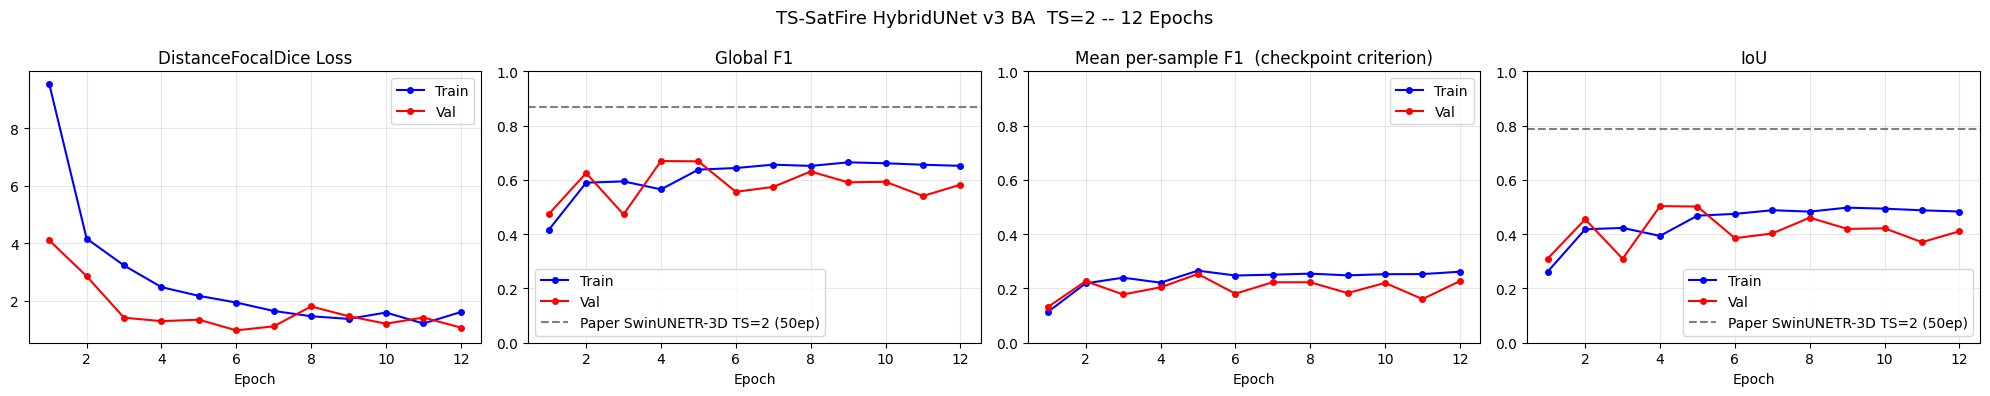

In [12]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val',   markersize=4)
axes[0].set_title('DistanceFocalDice Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_F1'], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs, history['val_F1'],   'r-o', label='Val',   markersize=4)
axes[1].axhline(0.869, color='gray', linestyle='--', linewidth=1.5,
                label='Paper SwinUNETR-3D TS=2 (50ep)')
axes[1].set_title('Global F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['train_mF1'], 'b-o', label='Train', markersize=4)
axes[2].plot(epochs, history['val_mF1'],   'r-o', label='Val',   markersize=4)
axes[2].set_title('Mean per-sample F1  (checkpoint criterion)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(epochs, history['train_IoU'], 'b-o', label='Train', markersize=4)
axes[3].plot(epochs, history['val_IoU'],   'r-o', label='Val',   markersize=4)
axes[3].axhline(0.789, color='gray', linestyle='--', linewidth=1.5,
                label='Paper SwinUNETR-3D TS=2 (50ep)')
axes[3].set_title('IoU')
axes[3].set_xlabel('Epoch')
axes[3].set_ylim(0, 1)
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'TS-SatFire HybridUNet v3 BA  TS=2 -- {NUM_EPOCHS} Epochs', fontsize=13)
plt.tight_layout()
if SAVE_FIGURES:
    path = os.path.join(OUTPUT_DIR, 'training_curves_v3.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved {path}')
plt.show()

## Output files

Upload these four files as a Kaggle dataset before running the inference notebook:

- `hybridunet_v3_ba_best.pt` -- best model weights (checkpoint criterion: mean per-sample val F1)
- `norm_stats_v3.npz` -- normalisation statistics (means, stds, clip_lo, clip_hi)
- `run_meta_v3.json` -- full run config including BOTTLENECK, INFER_THRESHOLD and split info
- `history_v3.json` -- per-epoch train/val metrics

In [13]:
print('Training notebook complete.')
print('=' * 60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath)
    unit  = 'KB' if size < 1024**2 else 'MB'
    val   = size/1024 if unit=='KB' else size/1024**2
    print(f'  {fname:<50}  {val:6.1f} {unit}')
print()
print('Upload the following to a Kaggle dataset:')
print(f'  {CKPT_PATH}')
print(f'  {STATS_PATH}')
print(f'  {META_PATH}')
print(f'  {os.path.join(OUTPUT_DIR, "history_v3.json")}')

Training notebook complete.
  __notebook__.ipynb                                   299.6 KB
  channel_stats_v3.png                                  69.0 KB
  eda_stats_v3.png                                      62.7 KB
  history_v3.json                                        2.2 KB
  hybridunet_v3_ba_best.pt                              41.8 MB
  norm_stats_v3.npz                                      1.4 KB
  run_meta_v3.json                                       3.8 KB
  training_curves_v3.png                               116.8 KB

Upload the following to a Kaggle dataset:
  /kaggle/working/hybridunet_v3_ba_best.pt
  /kaggle/working/norm_stats_v3.npz
  /kaggle/working/run_meta_v3.json
  /kaggle/working/history_v3.json
